In [1]:
# Grab_Strategies.cpp
# ===============================================================================
# #    This sample shows the use of the Instant Camera grab strategies.
# ===============================================================================

import sys
import time

from pypylon import pylon
import matplotlib.pyplot as plt
# from samples.imageeventprinter import ImageEventPrinter
# from samples.configurationeventprinter import ConfigurationEventPrinter

# The exit code of the sample application.
exitCode = 0

# Create an instant camera object for the camera device found first.
camera = pylon.InstantCamera(pylon.TlFactory.GetInstance().CreateFirstDevice())


In [2]:

# The parameter MaxNumBuffer can be used to control the count of buffers
# allocated for grabbing. The default value of this parameter is 10.
camera.MaxNumBuffer.Value = 15

# Open the camera.
camera.Open()


In [3]:
%pprint on

Pretty printing has been turned OFF


In [4]:
for i in dir(camera):
    print( i ) 

AOI
AcquisitionFrameCount
AcquisitionFrameRateAbs
AcquisitionFrameRateEnable
AcquisitionMode
AcquisitionStart
AcquisitionStartEventData
AcquisitionStartEventStreamChannelIndex
AcquisitionStartEventTimestamp
AcquisitionStartOvertriggerEventData
AcquisitionStartOvertriggerEventStreamChannelIndex
AcquisitionStartOvertriggerEventTimestamp
AcquisitionStartStopExecutionEnable
AcquisitionStartWaitEventData
AcquisitionStartWaitEventStreamChannelIndex
AcquisitionStartWaitEventTimestamp
AcquisitionStatus
AcquisitionStatusSelector
AcquisitionStop
AcquisitionTrigger
ActionCommandCount
ActionControl
ActionDeviceKey
ActionGroupKey
ActionGroupMask
ActionLateEventData
ActionLateEventStreamChannelIndex
ActionLateEventTimestamp
ActionSelector
AnalogControls
Attach
AutoExposureTimeAbsLowerLimit
AutoExposureTimeAbsUpperLimit
AutoExposureTimeLowerLimitRaw
AutoExposureTimeUpperLimitRaw
AutoFunctionAOIHeight
AutoFunctionAOIOffsetX
AutoFunctionAOIOffsetY
AutoFunctionAOISelector
AutoFunctionAOIUsageIntensity
A

In [5]:

# Register the standard configuration event handler for enabling software triggering.
# The software trigger configuration handler replaces the default configuration
# as all currently registered configuration handlers are removed by setting the registration mode to RegistrationMode_ReplaceAll.

camera.RegisterConfiguration(pylon.SoftwareTriggerConfiguration(), 
                             pylon.RegistrationMode_ReplaceAll,
                             pylon.Cleanup_Delete)

# For demonstration purposes only, add sample configuration event handlers to print out information
# about camera use and image grabbing.

# camera.RegisterConfiguration(ConfigurationEventPrinter(), pylon.RegistrationMode_Append, pylon.Cleanup_Delete)
# camera.RegisterImageEventHandler(ImageEventPrinter(), pylon.RegistrationMode_Append, pylon.Cleanup_Delete)

# Print the model name of the camera.
print("Using device ", camera.GetDeviceInfo().GetModelName())


Using device  acA720-290gm


In [6]:
print("Grab using the GrabStrategy_OneByOne default strategy:")

# The GrabStrategy_OneByOne strategy is used. The images are processed
# in the order of their arrival.
camera.StartGrabbing(pylon.GrabStrategy_OneByOne)
# In the background, the grab engine thread retrieves the
# image data and queues the buffers into the internal output queue.


Grab using the GrabStrategy_OneByOne default strategy:


In [7]:
camera.ExecuteSoftwareTrigger()

In [8]:

# Issue software triggers. For each call, wait up to 200 ms until the camera is ready for triggering the next image.
if camera.WaitForFrameTriggerReady(200, pylon.TimeoutHandling_ThrowException):
    camera.ExecuteSoftwareTrigger()
    print("ExecuteSoftwareTrigger")

# Check that grab results are waiting.
if camera.GetGrabResultWaitObject().Wait(0):
    print("Grab results wait in the output queue.")

# All triggered images are still waiting in the output queue
# and are now retrieved.
# The grabbing continues in the background, e.g. when using hardware trigger mode,
# as long as the grab engine does not run out of buffers.
buffersInQueue = 0
while True:    
    grabResult = camera.RetrieveResult(0, pylon.TimeoutHandling_Return)
    if not grabResult : break
    else: last_result = grabResult
    buffersInQueue += 1
    print("Retrieved ", buffersInQueue, " grab results from output queue.")


ExecuteSoftwareTrigger
Grab results wait in the output queue.
Retrieved  1  grab results from output queue.
Retrieved  2  grab results from output queue.
Retrieved  3  grab results from output queue.
Retrieved  4  grab results from output queue.
Retrieved  5  grab results from output queue.
Retrieved  6  grab results from output queue.
Retrieved  7  grab results from output queue.
Retrieved  8  grab results from output queue.
Retrieved  9  grab results from output queue.
Retrieved  10  grab results from output queue.
Retrieved  11  grab results from output queue.
Retrieved  12  grab results from output queue.
Retrieved  13  grab results from output queue.


In [14]:
last_result.GetTimeStamp()

237375000036

In [88]:
buffersInQueue = 0
while True:    
    grabResult = camera.RetrieveResult(0, pylon.TimeoutHandling_Return)
    if not grabResult : break
    else: last_result = grabResult
    buffersInQueue += 1
    print("Retrieved ", buffersInQueue, " grab results from output queue.")


Retrieved  1  grab results from output queue.
Retrieved  2  grab results from output queue.
Retrieved  3  grab results from output queue.
Retrieved  4  grab results from output queue.
Retrieved  5  grab results from output queue.


<class 'pypylon.pylon.GrabResult'>
<class 'numpy.ndarray'>
SizeX:  720
SizeY:  540
Gray value of first pixel:  0


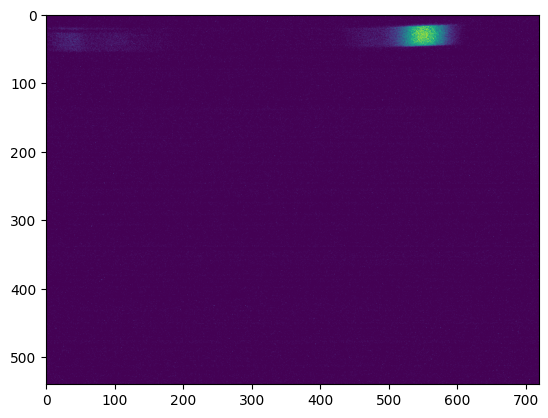

In [17]:

if last_result.GrabSucceeded():
    print(type(last_result))    
    print(type(last_result.Array)) 

    print("SizeX: ", last_result.Width)
    print("SizeY: ", last_result.Height)
    img = last_result.Array
    plt.imshow(img)

    print("Gray value of first pixel: ", img[0, 0])
else:
    print("Error: ", last_result.ErrorCode, last_result.ErrorDescription)



In [50]:


# Stop the grabbing.
camera.StopGrabbing()

In [19]:
print("Grab using strategy GrabStrategy_LatestImageOnly:")

# The GrabStrategy_LatestImageOnly strategy is used. The images are processed
# in the order of their arrival but only the last received image
# is kept in the output queue.
# This strategy can be useful when the acquired images are only displayed on the screen.
# If the processor has been busy for a while and images could not be displayed automatically
# the latest image is displayed when processing time is available again.
# camera.StartGrabbing(100, pylon.GrabStrategy_LatestImageOnly)

camera.StartGrabbing(pylon.GrabStrategy_LatestImageOnly)


Grab using strategy GrabStrategy_LatestImageOnly:


In [20]:

# Execute the software trigger, wait actively until the camera accepts the next frame trigger or until the timeout occurs.
for i in range(3):
    if camera.WaitForFrameTriggerReady(200, pylon.TimeoutHandling_ThrowException):
        print("ExecuteSoftwareTrigger.")
        camera.ExecuteSoftwareTrigger()


ExecuteSoftwareTrigger.
ExecuteSoftwareTrigger.
ExecuteSoftwareTrigger.


In [21]:

# Wait for all images.
time.sleep(0.2)

# Check whether the grab result is waiting.
if camera.GetGrabResultWaitObject().Wait(0):
    print("A grab result waits in the output queue.")


A grab result waits in the output queue.


In [22]:

# Only the last received image is waiting in the internal output queue
# and is now retrieved.
# The grabbing continues in the background, e.g. when using hardware trigger mode.
buffersInQueue = 0

while True:
    grabResult = camera.RetrieveResult(0, pylon.TimeoutHandling_Return)
    if not grabResult.IsValid():
        break
    else:
        last_result = grabResult
    print("Skipped ", grabResult.GetNumberOfSkippedImages(), " images.")
    buffersInQueue += 1

print("Retrieved ", buffersInQueue, " grab result from output queue.")


Skipped  23  images.
Retrieved  1  grab result from output queue.


In [23]:
last_result.Array

array([[ 4,  0,  0, ...,  0,  6,  0],
       [ 0,  0, 13, ...,  1,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  4,  0],
       [ 0,  0,  0, ...,  6,  1,  5],
       [ 8,  0,  0, ...,  1,  0,  0]], dtype=uint16)

RuntimeException: No grab result data is referenced. Cannot access NULL pointer. : RuntimeException thrown (file 'grabresultptr.cpp', line 87)

In [12]:
camera.Close()